# Final evaluation for all models

This notebook covers evaluation of all ten models trained across the three approaches, all scored on the **official IPN Hand test split** with the shared `src/evaluation/metrics.py` module, so every number below is directly comparable.

| Approach | Models | Notebook |
|---|---|---|
| Landmark statistics (aggregated) | KNN, SVM linear, SVM RBF, Random Forest | `04_classical_models.ipynb` |
| Landmark sequences (RNN) | LSTM, GRU, BiGRU, BiLSTM | `05_lstm_models.ipynb` |
| Raw video clips (pixels) | 3D CNN from scratch, R(2+1)D-18 pretrained | `06_3dcnn_models.ipynb` |

Contents:
1. Load all saved results
2. Joint results table
3. Overall metric comparison
4. Per-class comparison
5. Confusion matrices
6. Conclusions

## 1. Load all saved results

Every notebook saves its final test-set metrics as JSON in `results/`, so nothing is retrained here.

In [16]:
import sys
sys.path.insert(0, '..')

import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
FIG_DIR = "../results/figures/comparison"
os.makedirs(FIG_DIR, exist_ok=True)

# (json file, display name, approach)
MODEL_FILES = [
    ("KNN_results.json",           "KNN",            "Landmark stats"),
    ("SVM_linear_results.json",    "SVM linear",     "Landmark stats"),
    ("SVM_rbf_results.json",       "SVM RBF",        "Landmark stats"),
    ("RandomForest_results.json",  "Random Forest",  "Landmark stats"),
    ("LSTM_results.json",          "LSTM",           "Landmark seq"),
    ("GRU_results.json",           "GRU",            "Landmark seq"),
    ("BiGRU_final.json",         "BiGRU",          "Landmark seq"),
    ("BiLSTM_results.json",          "BiLSTM",         "Landmark seq"),
    ("3dcnn_scratch_results.json", "3D CNN scratch", "Video pixels"),
    ("r2plus1d_results.json",      "R(2+1)D-18",     "Video pixels"),
]

results = {}
for filename, display_name, approach in MODEL_FILES:
    with open(os.path.join(RESULTS_DIR, filename)) as f:
        data = json.load(f)
    data['display_name'] = display_name
    data['approach'] = approach
    results[display_name] = data

print(f"Loaded {len(results)} model results")

Loaded 10 model results


## 2. Joint results table

All models scored on the official IPN Hand test split with the shared `full_evaluation()`. Parameter counts do not apply to KNN, SVM and Random Forest.

Training and inference times are deliberately **not** compared here. The three branches were trained on different hardware (local CPU/MPS for the classical and RNN models, Kaggle GPU for the pixel models) and their timings were measured under different protocols, so putting them in one column would invite conclusions the measurements cannot support. Accuracy, F1 and parameter count are hardware-independent, and those are what this comparison rests on.

In [17]:
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Approach': r['approach'],
        'Accuracy': r['accuracy'],
        'F1 (weighted)': r['f1_weighted'],
        'F1 (macro)': r['f1_macro'],
        'Parameters': r.get('parameters'),
    })

comparison_df = pd.DataFrame(rows).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)

comparison_df.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}', 'F1 (macro)': '{:.4f}',
    'Parameters': '{:,.0f}',
}, na_rep='-').background_gradient(subset=['Accuracy', 'F1 (weighted)', 'F1 (macro)'], cmap='Blues')

,Model,Approach,Accuracy,F1 (weighted),F1 (macro),Parameters
0,R(2+1)D-18,Video pixels,0.9410,0.9411,0.9184,"31,306,794"
1,BiGRU,Landmark seq,0.8883,0.8876,0.8438,"2,988,941"
2,BiLSTM,Landmark seq,0.8774,0.8761,0.8372,"674,701"
3,SVM RBF,Landmark stats,0.8474,0.8478,0.7723,-
4,SVM linear,Landmark stats,0.8447,0.8452,0.7623,-
5,GRU,Landmark seq,0.8483,0.8444,0.7718,"206,477"
6,Random Forest,Landmark stats,0.8029,0.7999,0.7075,-
7,LSTM,Landmark seq,0.8047,0.7987,0.7198,"272,269"
8,KNN,Landmark stats,0.6866,0.6743,0.5841,-
9,3D CNN scratch,Video pixels,0.5577,0.5542,0.5606,"1,199,821"


**Reading the table**
 
R(2+1)D-18 leads outright at 0.941 weighted F1 - about 5 points clear of the next tier, BiGRU (0.888) and BiLSTM (0.876), which remain close to each other. Below them, a dense middle band - GRU, SVM RBF, SVM linear - all land between 0.844 and 0.848, with LSTM (0.799) and Random Forest (0.800) just underneath.
 
The two clear outliers are at the bottom: KNN (0.674) and the from-scratch 3D CNN (0.554). They fail for opposite reasons - KNN because a distance metric over aggregated statistics discards temporal structure, and the 3D CNN because ~3,100 clips are not enough to learn useful spatiotemporal filters from raw pixels.
 
Macro F1 separates the models more sharply than accuracy does, because it weights the eleven rare classes equally with the two dominant `Point` classes. On that metric the ranking is similar, but the spread is informative: R(2+1)D-18 (0.918) pulls further ahead of BiGRU (0.844) and BiLSTM (0.837), and both stay well clear of the classical models (0.584-0.772). The from-scratch 3D CNN's macro F1 (0.561) is essentially equal to its weighted F1 (0.554) - trained to saturation, it no longer collapses a dominant class, so it is balanced across classes even though its overall level stays low.

## 3. Overall metric comparison

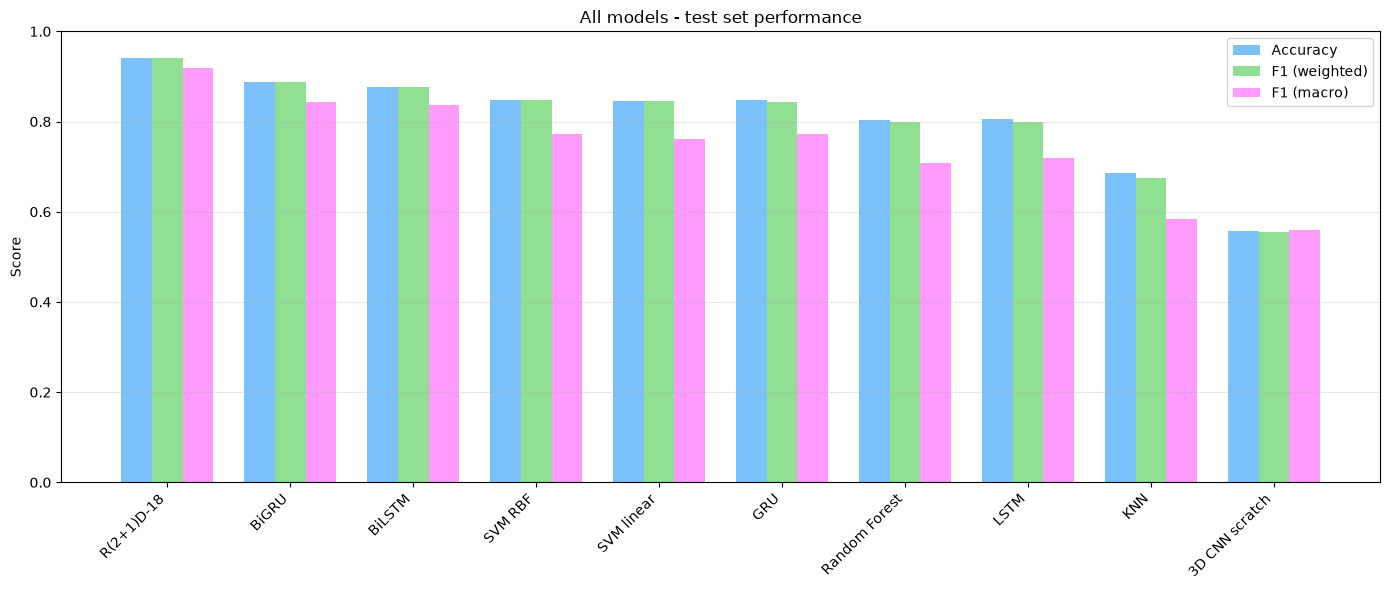

In [18]:
plot_df = comparison_df.copy()
x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, plot_df['Accuracy'], width, label='Accuracy', color="#7BC1FB")
ax.bar(x, plot_df['F1 (weighted)'], width, label='F1 (weighted)', color="#90DF92")
ax.bar(x + width, plot_df['F1 (macro)'], width, label='F1 (macro)', color="#FF9BFC")

ax.set_ylabel('Score')
ax.set_title('All models - test set performance')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "all_models_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

The three metrics order the models identically. The macro F1 bar is consistently the shortest - every model finds the rare classes harder than the frequent ones, but the size of that drop is itself informative: it is small for the deep sequence models (BiGRU 0.888 to 0.844, BiLSTM 0.876 to 0.837) and large for the classical ones (KNN 0.674 to 0.584, Random Forest 0.800 to 0.707), meaning the classical models lean much more heavily on the two dominant `Point` classes for their score.

## 4. Per-class comparison

Per-class F1 is available for the models that stored it (the classical models directly, the RNN models inside their saved classification report). BiLSTM, 3D CNN and R(2+1)D-18 saved only summary metrics, so they are discussed from their own notebooks rather than shown here.

In [19]:
from src.evaluation.metrics import CLASS_NAMES

# Get per-class F1 from either the stored dict or the classification report text
def parse_per_class_f1(result):
    
    if 'per_class_f1' in result:
        return result['per_class_f1']
    if 'report' in result:
        per_class = {}
        for line in result['report'].split('\n'):
            for class_name in CLASS_NAMES:
                if line.strip().startswith(class_name):
                    per_class[class_name] = float(line.split()[-2])
        return per_class
    return None

per_class_data = {}
for name, r in results.items():
    parsed = parse_per_class_f1(r)
    if parsed and len(parsed) == len(CLASS_NAMES):
        per_class_data[name] = parsed

per_class_df = pd.DataFrame(per_class_data).reindex(CLASS_NAMES)
print("Models with per-class data:", list(per_class_df.columns))

per_class_df.style.format('{:.2f}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)

Models with per-class data: ['KNN', 'SVM linear', 'SVM RBF', 'Random Forest', 'LSTM', 'GRU']


,KNN,SVM linear,SVM RBF,Random Forest,LSTM,GRU
Point-1f,0.80,0.98,0.96,0.94,0.93,0.96
Point-2f,0.84,0.97,0.97,0.95,0.92,0.96
Click-1f,0.29,0.49,0.48,0.42,0.59,0.39
Click-2f,0.26,0.55,0.56,0.41,0.41,0.50
Throw-up,0.48,0.82,0.84,0.79,0.82,0.76
Throw-down,0.82,0.93,0.94,0.91,0.90,0.86
Throw-left,0.89,0.96,0.96,0.95,0.97,1.00
Throw-right,0.81,0.83,0.88,0.87,0.88,0.82
Open-twice,0.65,0.84,0.87,0.81,0.84,0.81
DblClick-1f,0.40,0.55,0.57,0.43,0.10,0.64


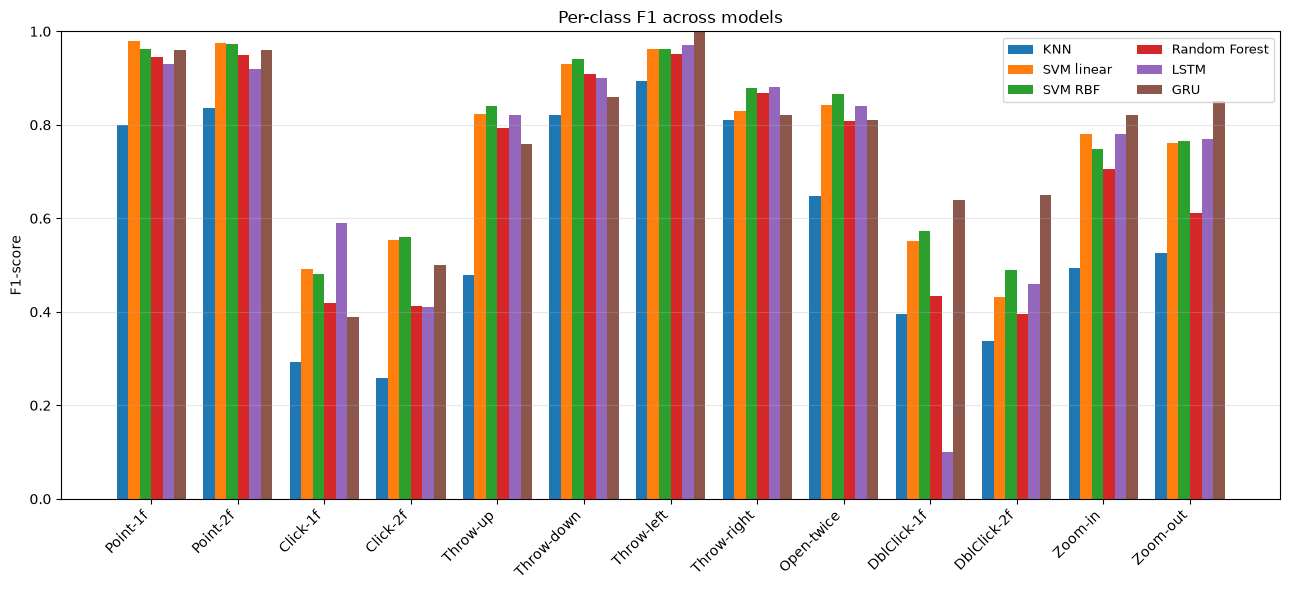

In [20]:
fig, ax = plt.subplots(figsize=(13, 6))

n_models = len(per_class_df.columns)
x = np.arange(len(CLASS_NAMES))
width = 0.8 / n_models

for i, model in enumerate(per_class_df.columns):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, per_class_df[model], width, label=model)

ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 across models')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "per_class_f1_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


**The same four classes are hardest for every model.** `Click-1f`, `Click-2f`, `DblClick-1f` and `DblClick-2f` are the lowest-scoring classes for every single model in the table - 0.26-0.40 for KNN, 0.40-0.43 for Random Forest, 0.43-0.57 for the SVMs, and higher but still lowest-in-class for the RNNs (BiGRU and BiLSTM from their own notebooks). No other class family behaves this way: excluding KNN, the two `Point` classes score 0.94-0.98 everywhere and the `Throw` family 0.76-1.00.
 
The fact that this pattern survives four fundamentally different algorithms says it is a property of the **task**, not of any of the models. These four gestures share a hand shape and a motion, so they differ only in how many fingers are extended and how many times the motion repeats. Counting repetitions is exactly what the aggregated statistics throw away, and the error analysis in `05_lstm_models.ipynb` shows even the sequence models trip on it - natural hand tremor after a single click reads as a second click.
 
**Where the sequence models earn their advantage** is visible here rather than in the overall scores: on the Click/DblClick family the best RNNs gain roughly 0.10-0.20 F1 over the best classical models, while on the easy classes the two families are within a point or two of each other. The overall gap between the SVMs and the best RNN is therefore concentrated almost entirely in this one gesture family.
 
One outlier worth flagging: plain LSTM scores 0.09 on `DblClick-1f` - far below every other model including KNN, and out of line with its own score on `Click-1f`. It is the weakest sequence architecture overall (0.799 accuracy), and a near-total collapse on one class looks more like that class being absorbed into a neighbour than like uniform weakness; the LSTM confusion matrix in `05_lstm_models.ipynb` would confirm where those samples went.

## 5. Confusion matrices

Saved by each notebook via the shared `full_evaluation()`. Shown here side by side for the best model of each approach.

**Landmark statistics - SVM RBF**

![SVM RBF](../results/figures/classical_models/confusion_SVM_rbf.png)

**Landmark sequences - BiLSTM**

![BiLSTM](../results/figures/confusion_BiLSTM_final.png)

**Video pixels - R(2+1)D-18**

![R(2+1)D-18](../results/kaggleB/confusion_R2plus1D_18.png)

All three share a strong diagonal and the same off-diagonal cluster in the Click/DblClick block. The difference is in how dense that cluster is: SVM RBF misroutes many `DblClick-2f` samples into `Click-2f`, while R(2+1)D-18 keeps almost the whole family on-diagonal, with `DblClick-2f` its only slightly weaker class - the same confusion direction as SVM RBF, just far less severe.
 
For contrast, the from-scratch 3D CNN is the weakest model in the comparison (0.558 accuracy). Even trained to saturation it still confuses the two static `Point` classes and the Click/DblClick family, because from raw pixels alone - and only ~3,100 clips - it cannot reliably tell one raised finger from two. Fine-tuning a pretrained network fixes precisely that failure, which is why R(2+1)D-18 gains ~38 accuracy points over it from the same pixel input.

## 6. Conclusions

### 6.1 Landmark-based vs pixel-based
 
Pixel-based transfer learning holds the outright accuracy lead. R(2+1)D-18 (0.941 weighted F1, ~31M parameters) beats the best landmark model, BiGRU (0.888, 3.0M parameters), by 5.3 points - a clear gap, not noise. The landmark models remain far smaller: BiLSTM in particular reaches 0.876 with only 675k parameters, roughly 2% of R(2+1)D-18's size.
 
The reason the pixel branch needed transfer learning at all is data volume. MediaPipe has already solved the hard vision problem (locating the hand and its 21 joints), so the landmark models only have to learn gesture dynamics from 63 numbers per frame. The pixel models must learn hand detection, pose and motion together from ~3,100 clips, which the from-scratch 3D CNN visibly cannot do (0.558 accuracy even trained to saturation). Transfer learning from Kinetics-400 doesn't just close that gap, it overtakes the landmark approach entirely - evidence that the from-scratch model's ceiling was data volume, not the pixel representation itself.
 
The trade-off is dependency and cost: the landmark branch inherits MediaPipe's failure modes (a frame with no detected hand contributes nothing) and discards texture and background information entirely, while R(2+1)D-18 needed a GPU to train and is ~46x larger. Which one "wins" depends on whether the deployment target can afford the pixel model's size for the extra points.
 
### 6.2 Classical models vs deep learning
 
The complexity is worth it, but by less than expected. SVM linear reaches 0.845 weighted F1 - only ~0.04 below BiGRU - with no GPU, no epochs, and by far the simplest training procedure of any model here. The best RNN needed a full training run to earn those points.
 
Macro F1 tells a different story: 0.762 for SVM linear against 0.844 for BiGRU, an ~8-point gap. The temporal models are not slightly better overall, they are substantially better on the hard, rare gestures and equivalent on the easy frequent ones. If the application only needs to tell `Point` from `Throw`, the SVM is the rational choice; if it needs `Click` from `DblClick`, the sequence model is not optional.
 
### 6.3 What each approach contributes
 
- **Aggregating a sequence into statistics is the single biggest information loss.** Mean, std,
  min and max over time cannot express *how many times* something happened. This is the root of
  the Click/DblClick ceiling that all four classical models hit.
- **Bidirectionality helps consistently** - LSTM to BiLSTM and GRU to BiGRU both improve, and
  help most on macro F1, i.e. on the rare classes. For an isolated clip the ending is as
  informative as the beginning.
- **Velocity features matter more than any hyperparameter.** Appending frame-to-frame
  differences raised validation accuracy from 0.772 to 0.823 in the RNN experiments; direction
  of motion is what separates `Throw-up` from `Throw-down`, and raw positions do not encode it.
- **Transfer learning is decisive when data is scarce.** ~38 accuracy points from the same
  architecture family (0.558 from scratch to 0.941 pretrained), purely from pretrained weights.
 
### 6.4 Best model per use case
 
| Requirement | Model | Why |
|---|---|---|
| Highest overall accuracy | R(2+1)D-18 | 0.941 weighted F1, a clear ~5-point lead over BiGRU (0.888), at far more parameters |
| Best landmark accuracy | BiGRU | 0.888 F1, the best of the landmark models, at 3.0M parameters |
| Strong accuracy, small model | BiLSTM | 0.876 F1 with only 675k parameters |
| Smallest / simplest | SVM linear | 0.845 F1, no GPU, no epochs, the simplest model to train and deploy |
| Best accuracy per parameter | GRU | 0.844 F1 with just 206k parameters |
| Interpretability | Random Forest | Feature importances identify which landmarks drive the decision |
 
### 6.5 Limitations and what would come next
 
- **Speed is not compared across branches.** The three branches were trained and timed on
  different hardware and under different protocols, so any single latency ranking would be an
  artefact of the setup rather than a property of the models. A fair comparison would require
  re-timing every model end-to-end (including preprocessing) on identical hardware.
- **This is isolated recognition, not continuous detection.** Every model classifies a gesture
  whose start and end frames come from the dataset's manual annotations. Detecting the gesture
  boundary in a live stream is a separate problem - the IPN Hand authors treat it as its own
  task - and would require training on the `Non-gesture` class that we dropped here.
- The **Click/DblClick family** caps every model. The RNN error analysis traces it to landmark
  jitter being read as a second click, which suggests trajectory smoothing before
  classification, or an explicit peak-counting feature, rather than a bigger model.
- **Two evaluation protocols coexist.** The classical models tuned hyperparameters with 5-fold
  stratified CV on the training split; the deep models used a subject-wise train/validation
  split. Both keep the official test split untouched until final evaluation, so the reported
  numbers are comparable, but the classical models' CV folds can place the same subject on both
  sides - a slightly more optimistic model-selection signal.
- A **fusion model** combining landmark geometry with pixel features is the obvious next step,
  since the two approaches fail on partly different classes.